# Exponencial (Ejemplo en clase)

La transforrmada inversa es:
 x = -ln(1-R)/λ

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as rnd 

In [2]:
def generador_exponencial(lambda_param , N):

    muestra = []
    for _ in range(N):

        #Obtenemos un número unifrome entre 0 y 1
        R = rnd.random()

        #Aplicamos la función inversa
        x = -(np.log(1-R)/lambda_param)

        #Lo guardamos en la lista
        muestra.append(x)
    return muestra

#Generamos los datos
datos = generador_exponencial(1.5 , 1000)

<function matplotlib.pyplot.show(close=None, block=None)>

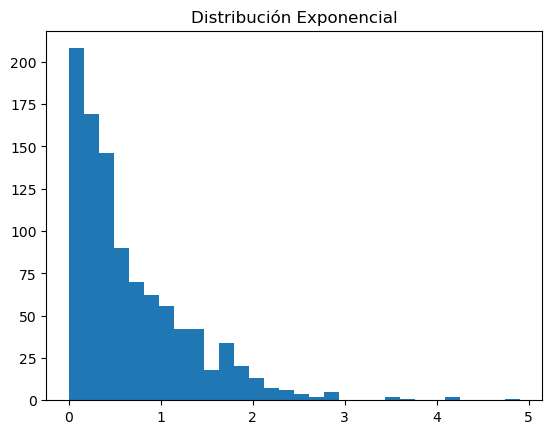

In [3]:
#Graficamos la lista

plt.hist(datos , bins=30)
plt.title('Distribución Exponencial')
plt.show

<br>

<hr style="border: 2px solid red;">

# Laplace

### *Metodo de la Transformada Inversa*

#### Paso 1 - Entender la Función de Densidad F(x)

> **Nota:** 
>
> &nbsp; *L(μ,b) = L(0,1)*
> 
> &nbsp;&nbsp;&nbsp; **μ** es la media, mediana y moda de la distribución.  
> &nbsp;&nbsp;&nbsp; Este valor nos indica el centro de la distribución;  
> &nbsp;&nbsp;&nbsp; en este caso, como es \(0\), significa que la curva es simétrica y está centrada en \(0\).
>
> &nbsp;&nbsp;&nbsp; **b** es un parametro de escala positivo.  
> &nbsp;&nbsp;&nbsp; Este valor controla que tan ancha es la curva  
> &nbsp;&nbsp;&nbsp; en este caso, como es 1, tiene un ancho "estandar"

La distribución L(0,1) tiene una función de distribucion definida como:  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$f(x)=\frac{1}{2}e^{-|x|}$

Como tenemos un valor absoluto |x| debemos divividirlo en **2 regiones**:  
&nbsp;&nbsp;&nbsp; **Si x<0:  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$f(x)=\frac{1}{2}e^{x}$  
&nbsp;&nbsp;&nbsp; Si x>0**:  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$f(x)=\frac{1}{2}e^{-x}$  

#### Paso 2 - Calcular la Función de Distribución Acumulada F(x)

Debido a la división anterior devemos **integrar en 2 partes**:  
**Caso 1 - Cuando x<0**
 $$F(x) = \int_{-\infty}^{x} \frac{1}{2} e^t dt = \left[ \frac{1}{2} e^t \right]_{-\infty}^{x} = \frac{1}{2} e^x - 0 = \frac{1}{2} e^x$$

**Caso 2 - Cuando x$\ge$0**  
&nbsp;&nbsp;&nbsp; Como la integral debe empezar desde el extremo más izquierdo posible (-∞)  
&nbsp;&nbsp;&nbsp; debemos integrar desde menos infinito hasta x  
&nbsp;&nbsp;&nbsp; Luego, como la función cambia en x>0 debemos dividir la integral en dos:  
&nbsp;&nbsp;&nbsp; *(la primera parte es la obtenida anteriormente, evaluada en x=0)*
$$
\begin{aligned}
F(x) &= \frac{1}{2} + \int_{0}^{x} \frac{1}{2} e^{-t} dt \\
F(x) &= \frac{1}{2} + \left[ -\frac{1}{2} e^{-t} \right]_{0}^{x} = \frac{1}{2} + \left( -\frac{1}{2} e^{-x} - \left( -\frac{1}{2} e^0 \right) \right) \\
F(x) &= \frac{1}{2} - \frac{1}{2} e^{-x} + \frac{1}{2} = 1 - \frac{1}{2} e^{-x}
\end{aligned}
$$

Por lo tanto, uniendo ambos casos obtenemos nuestra función por partes:
$$F(x) = \begin{cases} \frac{1}{2} e^x, & x < 0 \\ 1 - \frac{1}{2} e^{-x}, & x \geq 0 \end{cases}$$

#### Paso 3 - Aplicar la Transformada Inversa

>**Nota**:  
>Recordemos que según el **Teorema de la Transformada inversa**  
>si igualamos la Función Acumulada F(x) a una variable uniforme *r*~U(0.1), es decir, F(x)=r.  
>Y despejamos x, los valores resultantes de x seguirán la distribución deseada.

Como la función esta partida a la mitad, vamos a evaluar el punto medio (0)  
Si x=0 entonces **r = F(0) = 0.5**  
<br>
**Caso 1-Zona negativa**  
Primero igualamos r = F(x) cuando x<0:
$$r = \frac{1}{2} e^{-x}$$
Luego despejamos *x* y obtenemos:  
$$ x=ln(2r)$$  
<br>
**Caso 2-Zona positiva**  
Igualamos r = F(x) cuando x$\ge$0:
$$ r = 1 - \frac{1}{2} e^{-x}$$  
Despejando *x*:  
$$ x = -ln(2(1-r))$$

Por lo tanto, al juntar ambos despejes de los posibles valores que puede tomar r,  
obtenemos la solución:  
$$x = \begin{cases} ln(2r), & 0< r < \frac{1}{2} \\ -ln(2(1-r)), & \frac{1}{2} \le r <1 \end{cases}$$

### Código del Metodo (Laplace)

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import random as rnd
import numpy as np
import matplotlib.pyplot as plt

def generar_muestra_laplace(N):
    
    muestra = []
    for _ in range(N):

        #Obtenemos un número unifrome entre 0 y 1
        r = rnd.random()
        
        #Creamos las condiciones de solución
        if r < 0.5:
            x = np.log(2 * r)
        else:
            x = -np.log(2 * (1 - r))
            
        #Lo guardamos en la lista
        muestra.append(x)
    return muestra

# Generar 1k datos
datos_laplace = generar_muestra_laplace(1000)

### Histograma f(x)

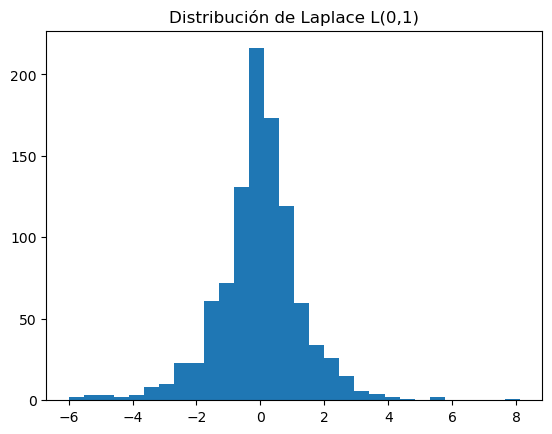

In [6]:
# Gráfica
plt.hist(datos_laplace, bins=30)
plt.title('Distribución de Laplace L(0,1)')
plt.show()

### Gráfica de Distribución Acumulada F(x)

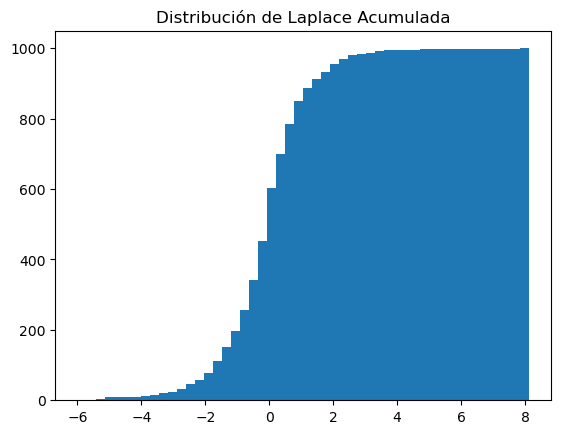

In [7]:
#Graficamos la Acumulada para comprobar F(x)
plt.hist(datos_laplace, bins=50, cumulative=True)
plt.title('Distribución de Laplace Acumulada')
plt.show()

### Media, Varianza y Desviación Estandar

Sabemos que para **Laplace**  
la **media** debe ser $μ$,  
la **varianza** debe ser $2b^2$  
y la **desviación estandar** debe ser $\sqrt{2b^2}$
<br>  
En este caso como $μ=0$ y $b=1$ tenemos que:  
media=0 , varianza=2 , desv. estandar= $\sqrt{2}$

#### Comprobación Mediante Código

In [26]:
media_L = np.mean(datos_laplace)
var_L = np.var(datos_laplace)
des_est_L = np.std(datos_laplace)

print(f"Media: {media_L:.4f}")
print(f"Varianza: {var_L:.4f}")
print(f"Desviación Est: {des_est_L:.4f}")

Media: -0.0259
Varianza: 1.8150
Desviación Est: 1.3472


<br>

<hr style="border: 2px solid red;">

# Weibull

#### Paso 1 - Entender la Función de Densidad F(x)

La distribución de **Weibull** esta dada por una función de distribución definida como:
$$f(x) = \alpha x^{\alpha-1}e^{-x^{\alpha}}, \quad x \geq 0$$


Como x$\geq$0 entonces solo tenemos una posible región

#### Paso 2 - Calcular F(x)

Como tenemos que considerar el extremo más izquierdo posible (0)  
debemos integrar desde 0 hasta x 
$$F(x) = \int_{0}^{x} \alpha t^{\alpha-1}e^{-t^{\alpha}} dt$$


Aplicando cambio de variable:  
&nbsp;&nbsp;&nbsp; $u=t^u$  
Esto implica que  
&nbsp;&nbsp;&nbsp; $du=\alpha t^{\alpha-1}dt$:

$$F(x) = \int_{0}^{x^{\alpha}} e^{-u} du = \left[-e^{-u}\right]_{0}^{x^{\alpha}} = -e^{-x^{\alpha}} - (-e^{0}) = 1 - e^{-x^{\alpha}}$$


$$F(x) = 1 - e^{-x^{\alpha}}, \quad x \geq 0$$


#### Paso 3 - Aplicar la Transformada Inversa

Igualamos F(x) a $w$~$(0,1)$:


$$w = F(x) = 1 - e^{-x^{\alpha}}$$

Despejando x:
$$x = (-\ln(1 - w))^{1/\alpha}$$


### Codigo del Método (Weibull)

In [9]:
def generador_weibull(N, alpha):
    
    muestra = []
    for _ in range(N):

        #Obtenemos un número uniforme entre 0 y 1
        w = np.random.rand()
        
        #Establecemos nuestra condición de solución
        x = (-np.log(1 - r)) ** (1 / alpha)
        
        muestra.append(x)
    return muestra

In [15]:
# Generamos 1k datos
datos_wei = generador_weibull(1000, 2.0)

### Histograma f(x)

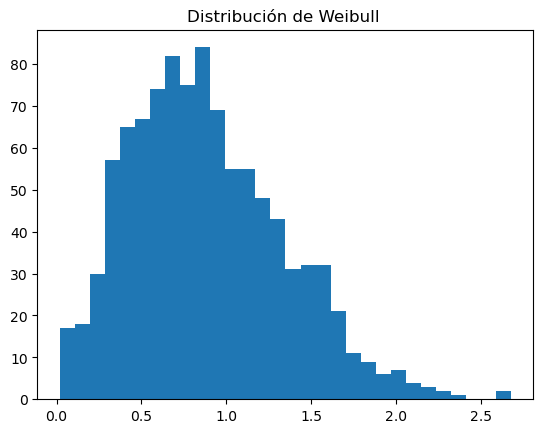

In [17]:
# Generar 1k datos (ejemplo con alpha = 2.0)
datos_weibull = generador_weibull(1000, 2.0)

# Gráfica
plt.hist(datos_wei, bins=30)
plt.title('Distribución de Weibull ')
plt.show()

### Gráfica de Distribución Acumulada F(x)

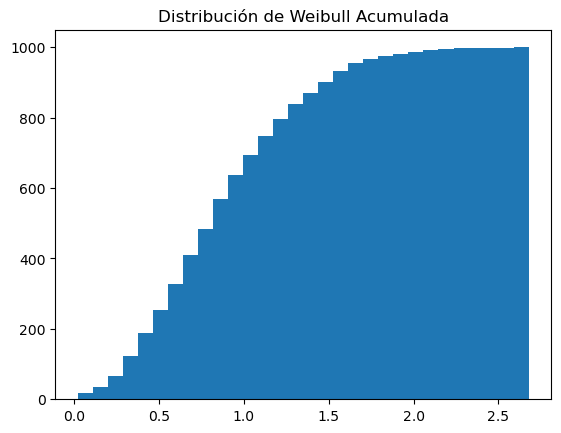

In [19]:
#Graficamos la Acumulada para comprobar F(x)
plt.hist(datos_wei, bins=30, cumulative=True)
plt.title('Distribución de Weibull Acumulada')
plt.show()

### Media, Varianza y Desviación Estandar

>Sabemos que para **Weibull**  
>la **media** debe ser $\Gamma\left(1 + \frac{1}{\alpha}\right)$,  
>la **varianza** debe ser $\Gamma\left(1 + \frac{2}{\alpha}\right) - \left[\Gamma\left(1 + \frac{1}{\alpha}\right)\right]^2$  
>y la **desviación estandar** debe ser $\sqrt{varianza}$  
>*$Γ$ representa a la función Gamma*

En este caso tenemos que $\alpha=2$, por lo tanto:  
media$\approx$ 0.8862 , varianza $\approx$ 0.2146 , desv. estandar $\approx$ 0.4633

#### Comprobación Mediante Código

In [29]:
media_W = np.mean(datos_wei)
var_W = np.var(datos_wei)
des_est_W = np.std(datos_wei)

print(f"Media {media_W:.4f}")
print(f"Varianza {var_W:.4f}")
print(f"Desviación Est.{des_est_W:.4f}")

Media 0.8851
Varianza 0.2049
Desviación Est.0.4527


<br>

<hr style="border: 2px solid red;">

# Gumbel

#### Paso 1 - Entender la Función de Densidad F(x)

> **Nota:** 
>
> &nbsp; *Gu(μ,β) = Gu(0,1)*
> 
> &nbsp;&nbsp;&nbsp; **μ** es la moda y el parametro de localización  
>
> &nbsp;&nbsp;&nbsp; **β** es un parametro de escala positivo.  
> &nbsp;&nbsp;&nbsp; Este valor controla que tan ancha es la curva  
> &nbsp;&nbsp;&nbsp; en este caso, como es 1, tiene un ancho "estandar"

Por lo tanto la distribución de **Gumbel** puede tomar valores en todo $\mathbb{R}$, por lo tanto la función esta dada por:  
$$f(x) = e^{-x}e^{-e^{-x}}$$


#### Paso 2 - Calcular F(x)

Integramos desde el extremos izquierdo ($-\infty$) hasta x:  
$$F(x) = \int_{-\infty}^{x} e^{-t}e^{-e^{-t}} dt$$


Aplicamos cambio de variable, tal que:  
$u = -e^{-t}$, entonces $du = -e^{-t}dt$



Evaluando los límites de integración:  
Cuando $t \to -\infty, u \to -\infty$;  
cuando $t = x , u = -e^{-x}$
$$F(x) = \int_{-\infty}^{-e^{-x}} e^u du = [e^u]_{-\infty}^{-e^{-x}} = e^{-e^{-x}} - 0 = e^{-e^{-x}}$$
Por lo tanto:
$$F(x) = e^{-e^{-x}}, \quad x \in \mathbb{R}$$

#### Paso 3 - Aplicar la Transformada Inversa

Igualamos F(x) a $g$~$(0,1)$:
$$g=e^{-e^{-x}}$$

Despejando x:
$$x = -\ln(-\ln(g))$$

### Codigo del Método (Gumbel)

In [50]:
def generador_gumbel(N):
    
    muestra = []
    for _ in range(N):
        g = np.random.rand()
        
        #Restringimos a g muy cercano a 0 para evitar ln(0) (indeterminados)
        r = max(g, 1e-15) 
        x = -np.log(-np.log(g))
        muestra.append(x)
    return muestra

In [51]:
datos_gum = generador_gumbel(1000)

### Histograma f(x)

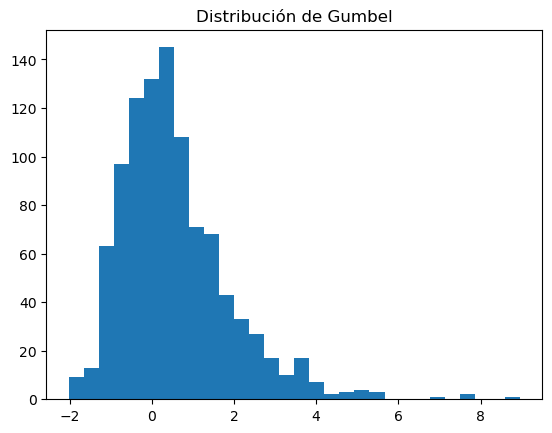

In [53]:
plt.hist(datos_gum, bins=30)
plt.title('Distribución de Gumbel')
plt.show()

### Gráfica de Distribución Acumulada F(x)

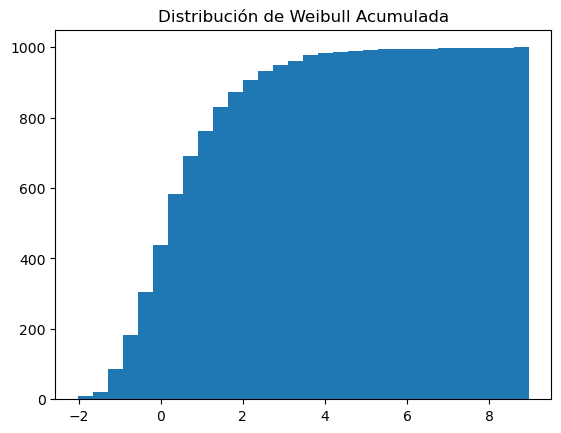

In [57]:
#Graficamos la Acumulada para comprobar F(x)
plt.hist(datos_gum, bins=30, cumulative=True)
plt.title('Distribución de Weibull Acumulada')
plt.show()

### Media, Varianza y Desviación Estandar

>Sabemos que para **Gumbel**:  
>la **media** es $\mu + \beta \gamma$  
>donde la contante $\gamma \approx 0.5772...$ ,  
>la **varianza** es $\frac{\pi^2 \beta^2}{6}$  
>y la **desviación estandar** es $\frac{\pi \beta}{\sqrt{6}}$


En este caso como $\mu = 0$ y $\beta = 1$ tenemos que:  
media $\approx$ 0.5772 , varianza $\approx$ 1.6449 , desv. estandar $\approx$ 1.2825

#### Comprobación Mediante Código

In [58]:
media_G = np.mean(datos_gum)
var_G = np.var(datos_gum)
des_est_G = np.std(datos_gum)

print(f"Media: {media_G:.4f}")
print(f"Varianza: {var_G:.4f}")
print(f"Desviación Est: {des_est_G:.4f}")

Media: 0.5619
Varianza: 1.7919
Desviación Est: 1.3386


<br>

<hr style="border: 2px solid red;">

# Cauchy

#### Paso 1 - Entender la Función de Densidad F(x)

La distribución de **Cauchy** esta dada por una función de distribución definida como:

$$f(x) = \frac{1}{\pi(1 + x^2)}$$

#### Paso 2 - Calcular F(x)

Integramos desde el extremos izquierdo ($-\infty$) hasta x:  
$$F(x) = \int_{-\infty}^{x} \frac{1}{\pi(1 + t^2)} dt = \frac{1}{\pi} [\arctan(t)]_{-\infty}^{x}$$  
Sabemos que $\lim_{t \to -\infty} \arctan(t) = -\frac{\pi}{2}$  
Sustituyendo:  
$$F(x) = \frac{1}{\pi} \left( \arctan(x) - \left(-\frac{\pi}{2}\right) \right) = \frac{1}{\pi} \arctan(x) + \frac{1}{2}$$  
Por lo tanto:  
$$F(x) = \frac{1}{2} + \frac{1}{\pi} \arctan(x), \quad x \in \mathbb{R}$$


#### Paso 3 - Aplicar la Transformada Inversa

Igualamos F(x) a $c$~$(0,1)$:

$$c=\frac{1}{2} + \frac{1}{\pi} \arctan(x)$$

Despejando x:
$$x = \tan\left(\pi\left(c - \frac{1}{2}\right)\right)$$


### Codigo del Método (Cauchy)

In [54]:
def generador_cauchy(N):
    
    muestra = []
    for _ in range(N):
        
        c = np.random.rand()
        x = np.tan(np.pi * (c - 0.5))
        muestra.append(x)
    return muestra

In [55]:
datos_cau = generador_cauchy(1000)

### Histograma f(x)

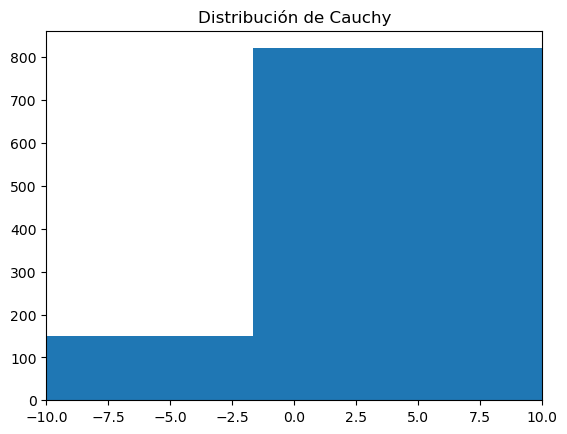

In [56]:
plt.hist(datos_cau, bins=30)
plt.title('Distribución de Cauchy')

# Acotamos para que la gráfica no se deforme por los valores extremos
plt.xlim(-10, 10)
plt.show()

### Gráfica de Distribución Acumulada F(x)

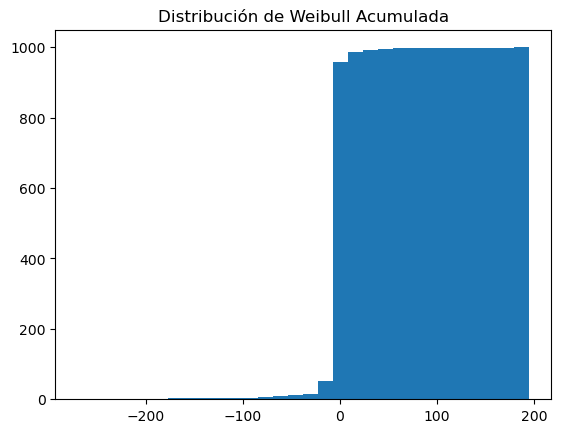

In [43]:
#Graficamos la Acumulada para comprobar F(x)
plt.hist(datos_cau, bins=30, cumulative=True)
plt.title('Distribución de Weibull Acumulada')
plt.show()

### Media, Varianza y Desviación Estandar

In [44]:
media_C = np.mean(datos_cau)
var_C = np.var(datos_cau)
des_est_C = np.std(datos_cau)

print(f"Media: {media_C:.4f}")
print(f"Varianza: {var_C:.4f}")
print(f"Desviación Est: {des_est_C:.4f}")

Media: -0.3473
Varianza: 279.2833
Desviación Est: 16.7118


<br>

<hr style="border: 2px solid red;">

# Pareto

#### Paso 1 - Entender la Función de Densidad F(x)

La distribución de **Pareto** esta dada por una función de distribución definida como:  
$$f(x) = \frac{\alpha}{x^{\alpha+1}}, \quad x \geq 1$$  
Para cualquier $x<1$ la densidad es nula

#### Paso 2 - Calcular F(x)

Integramos desde su límite inferior permitido (1):  
$$F(x) = \int_{1}^{x} \frac{\alpha}{t^{\alpha+1}} dt = \int_{1}^{x} \alpha t^{-\alpha-1} dt$$  
Aplicando la regla fundamental de integración para potencias:  
$$F(x) = \left[ \frac{\alpha t^{-\alpha}}{-\alpha} \right]_{1}^{x} = [-t^{-\alpha}]_{1}^{x} = -x^{-\alpha} - (-1^{-\alpha}) = 1 - x^{-\alpha}$$  
Por lo tanto:  
$$F(x) = 1 - x^{-\alpha}, \quad x \geq 1$$


#### Paso 3 - Aplicar la Transformada Inversa

Igualamos F(x) a $p$~$(0,1)$:
$$p=1 - x^{-\alpha}$$

Despejando x:
$$x = (1 - p)^{-1/\alpha}$$

### Codigo del Método (Pareto)

In [60]:
def generador_pareto(N, alpha):
    
    muestra = []
    for _ in range(N):
        p = np.random.rand()
        x = (1 / (1 - p)) ** (1 / alpha)
        muestra.append(x)
    return muestra

In [72]:
datos_par = generador_pareto(1000, 10)

### Histograma f(x)

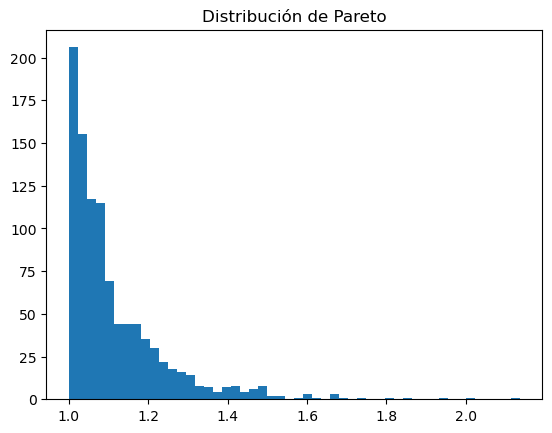

In [73]:
plt.hist(datos_par, bins=50)
plt.title('Distribución de Pareto')
plt.show()

### Media, Varianza y Desviación Estandar

In [74]:
media_P = np.mean(datos_par)
var_P = np.var(datos_par)
des_est_P = np.std(datos_par)

print(f"Media: {media_P:.4f}")
print(f"Varianza: {var_P:.4f}")
print(f"Desviación Est: {des_est_P:.4f}")

Media: 1.1162
Varianza: 0.0178
Desviación Est: 0.1333
